# TCGA-HNSC: Transcriptomics & Genetics Analysis

**Author:** Diana Lysenko  
**Date:** January 2026  
**Dataset:** UCSC Xena / TCGA-HNSC

**Transcriptomics:**
- PCA and UMAP dimensionality reduction
- Hierarchical clustering
- Differential expression analysis

**Genetics:**
- Filter VCF: chromosome 6, PASS, ALT = T

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import umap

PROJECT_ROOT = Path.home() / 'Documents' / 'tcga_hnsc_test'
DATA_DIR = PROJECT_ROOT / 'data' / 'transcriptomics'
FIG_DIR = PROJECT_ROOT / 'figures'
RES_DIR = PROJECT_ROOT / 'results'

for d in [DATA_DIR, FIG_DIR, RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Project: {PROJECT_ROOT}')

Project: /Users/dianalysenko/Documents/tcga_hnsc_test


## Part 1: Transcriptomics

In [2]:
expr_path = DATA_DIR / 'TCGA-HNSC.star_fpkm-uq.tsv.gz'
df = pd.read_csv(expr_path, sep='\t', compression='gzip')
print(f'Loaded: {df.shape[0]} genes x {df.shape[1]-1} samples')

gene_col = df.columns[0]
genes = df[gene_col].astype(str)
X = df.drop(columns=[gene_col])
X.index = genes
X = X.T
print(f'Matrix shape: {X.shape}')

Loaded: 60660 genes x 566 samples
Matrix shape: (566, 60660)


In [3]:
sample_type = X.index.str.extract(r'-(\d{2})[A-Z]$')[0]
is_tumor = (sample_type == '01')
is_normal = (sample_type == '11')

sample_info = pd.DataFrame({
    'is_tumor': is_tumor.values,
    'is_normal': is_normal.values
}, index=X.index)

print(f'Tumor: {is_tumor.sum()}, Normal: {is_normal.sum()}')

Tumor: 520, Normal: 44


In [4]:
print(f'Value range: {X.values.min():.2f} - {X.values.max():.2f}')
print('Data is log2-transformed, no additional transformation needed')

Value range: 0.00 - 17.01
Data is log2-transformed, no additional transformation needed


In [5]:
min_expr = 1
expressed = (X > min_expr).mean(axis=0) > 0.1
X_filtered = X.loc[:, expressed]
print(f'After expression filter: {X_filtered.shape[1]} genes')

gene_var = X_filtered.var(axis=0)
hvg_genes = gene_var.nlargest(2000).index
X_hvg = X_filtered[hvg_genes]
print(f'Selected {len(hvg_genes)} HVGs')

After expression filter: 16016 genes
Selected 2000 HVGs


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hvg)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_.sum()
print(f'PCA: {X_pca.shape[1]} components, {var_explained:.1%} variance explained')

PCA: 50 components, 75.3% variance explained


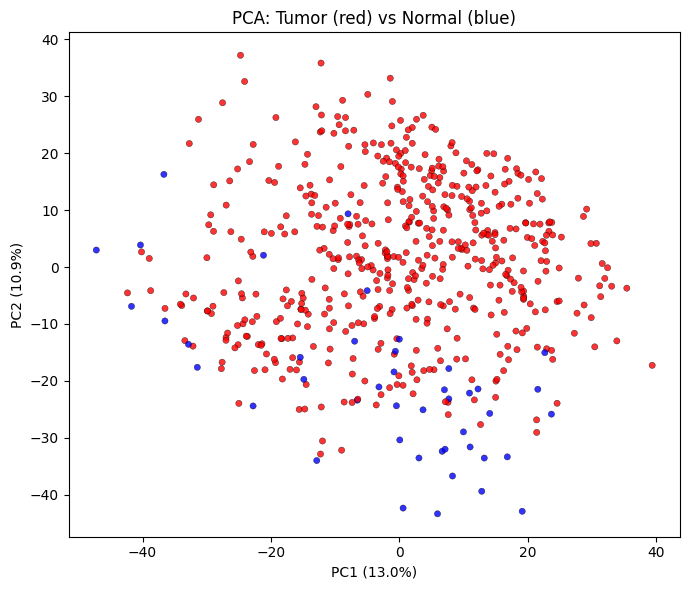

In [7]:
colors = sample_info.loc[X_hvg.index, 'is_normal'].map({True: 'blue', False: 'red'})

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0],
            X_pca[:, 1],
            c=colors,
            s=20,
            alpha=0.8,
            edgecolor='k',
            linewidth=0.3
)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA: Tumor (red) vs Normal (blue)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_tumor_normal.png', dpi=150)
plt.show()

/opt/miniconda3/envs/tcga-hnsc/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


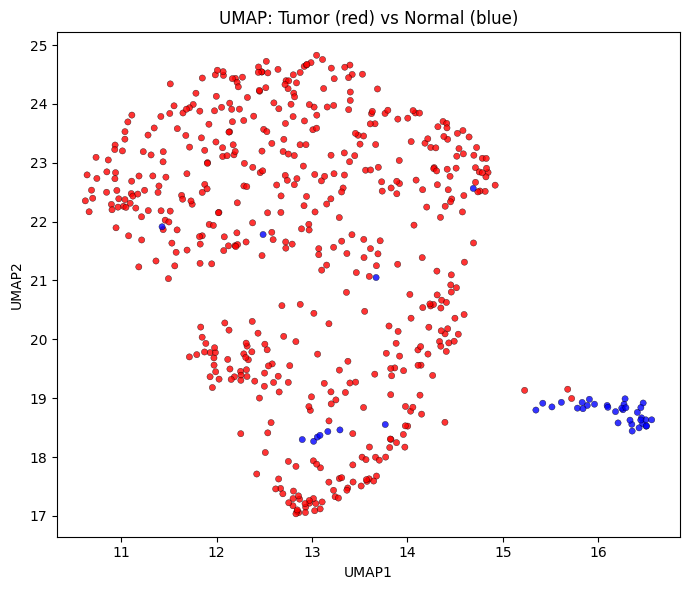

In [8]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_pca)

plt.figure(figsize=(7, 6))
plt.scatter(X_umap[:, 0],
            X_umap[:, 1],
            c=colors,
            s=20,
            alpha=0.8,
            edgecolor='k',
            linewidth=0.3
)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('UMAP: Tumor (red) vs Normal (blue)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'umap_tumor_normal.png', dpi=150)
plt.show()

In [9]:
Z = linkage(pdist(X_pca, metric='euclidean'), method='ward')

scores = {}
for k in range(2, 8):
    labels = fcluster(Z, k, criterion='maxclust')
    scores[k] = silhouette_score(X_pca, labels)
    
best_k = max(scores, key=scores.get)
print(f'Silhouette scores: {scores}')
print(f'Best k: {best_k}')

Silhouette scores: {2: 0.09976783407011058, 3: 0.11071164990332354, 4: 0.09667838172077349, 5: 0.08033841824317446, 6: 0.08332363051678786, 7: 0.08915741348456852}
Best k: 3


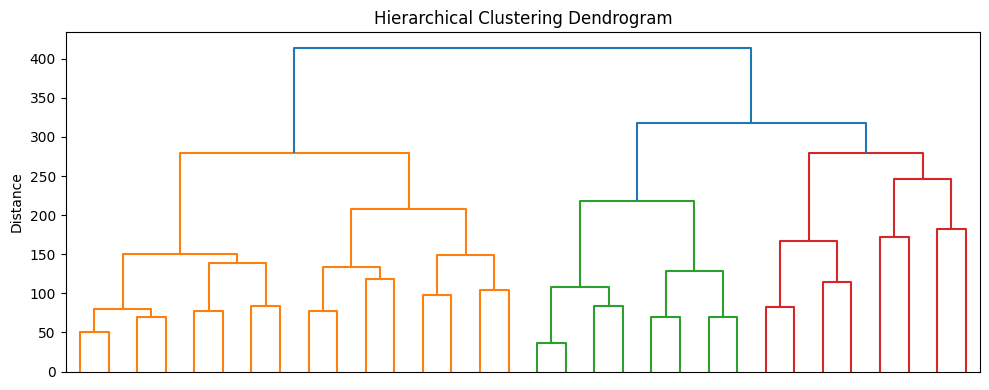

In [10]:
plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='level', p=4, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig(FIG_DIR / 'dendrogram.png', dpi=150)
plt.show()

In [11]:
k = 3
cluster_labels = fcluster(Z, k, criterion='maxclust')
clusters = pd.Series(cluster_labels, index=X_hvg.index, name='cluster')

print(f'Cluster sizes: {np.bincount(cluster_labels)[1:]}')

Cluster sizes: [280  39 247]


In [12]:
crosstab = pd.crosstab(clusters, sample_info.loc[clusters.index, 'is_normal'])
crosstab.columns = ['Tumor', 'Normal']
print(crosstab)
print('\nCluster 2 is mostly normal tissue - DE will compare tumor vs normal')

         Tumor  Normal
cluster               
1          279       1
2            4      35
3          239       8

Cluster 2 is mostly normal tissue - DE will compare tumor vs normal


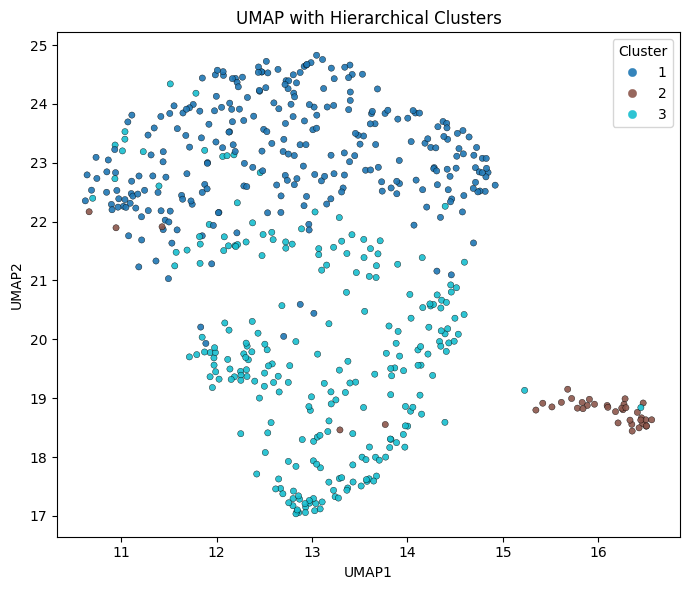

In [13]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_umap[:, 0],
                      X_umap[:, 1],
                      c=cluster_labels,
                      cmap='tab10', 
                      s=20,
                      alpha=0.9,
                      edgecolor='k',
                      linewidth=0.3
)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('UMAP with Hierarchical Clusters')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.savefig(FIG_DIR / 'umap_clusters.png', dpi=150)
plt.show()

In [14]:
counts_path = DATA_DIR / 'TCGA-HNSC.star_counts.tsv.gz'
counts_df = pd.read_csv(counts_path, sep='\t', compression='gzip')

gene_col = counts_df.columns[0]
X_counts = counts_df.drop(columns=[gene_col])
X_counts.index = counts_df[gene_col].astype(str)
X_counts = X_counts.T
print(f'Counts: {X_counts.shape}')

Counts: (566, 60660)


In [15]:
common = X_counts.index.intersection(clusters.index)
X_counts_sync = X_counts.loc[common]
clusters_sync = clusters.loc[common]
print(f'Common samples: {len(common)}')

Common samples: 566


In [16]:
lib_size = X_counts_sync.sum(axis=1)
X_cpm = X_counts_sync.div(lib_size, axis=0) * 1e6
X_logcpm = np.log2(X_cpm + 1)

In [17]:
expressed = (X_cpm > 1).sum(axis=0) >= 10
X_test = X_logcpm.loc[:, expressed]
print(f'Testing {X_test.shape[1]} genes')

mask_1 = clusters_sync == 1
mask_2 = clusters_sync == 2

X1 = X_test.loc[mask_1]
X2 = X_test.loc[mask_2]
print(f'Cluster 1: {mask_1.sum()} samples, Cluster 2: {mask_2.sum()} samples')

t_stat, pvals = ttest_ind(X1.values, X2.values, axis=0, equal_var=False)
log2fc = X1.mean(axis=0) - X2.mean(axis=0)

de = pd.DataFrame({'log2FC': log2fc, 'pval': pvals}, index=X_test.columns)
de = de.dropna()

Testing 53931 genes
Cluster 1: 280 samples, Cluster 2: 39 samples


In [18]:
de['fdr'] = multipletests(de['pval'], method='fdr_bh')[1]
de['abs_log2FC'] = de['log2FC'].abs()

sig = de[de['fdr'] < 0.05]
print(f'Significant genes (FDR<0.05): {len(sig)}')

Significant genes (FDR<0.05): 21523


In [19]:
top10 = de.nsmallest(10, 'fdr')
print(top10[['log2FC', 'fdr']])

                      log2FC           fdr
Ensembl_ID                                
ENSG00000113396.13 -2.330870  1.763702e-53
ENSG00000196616.14 -2.625870  5.832044e-53
ENSG00000181234.9  -2.306382  9.030624e-53
ENSG00000124253.11 -2.574058  5.255857e-52
ENSG00000137960.6  -0.746141  7.711759e-51
ENSG00000072133.11 -1.825823  4.025312e-48
ENSG00000181092.10 -3.931583  1.039294e-47
ENSG00000135063.19 -0.767540  5.834596e-47
ENSG00000182389.20 -1.165441  1.058519e-46
ENSG00000106078.19 -0.603628  1.129262e-46


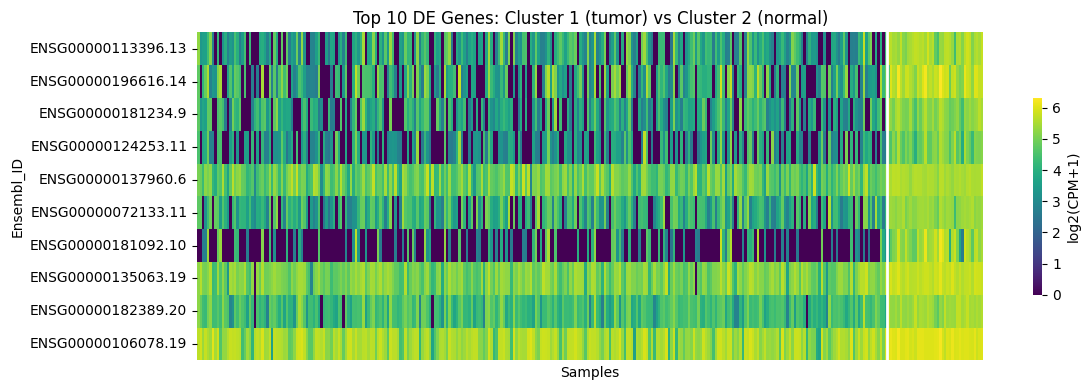

In [20]:
top_genes = top10.index.tolist()
samples_12 = clusters_sync[clusters_sync.isin([1, 2])].sort_values().index
heat = X_logcpm.loc[samples_12, top_genes].T

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heat, cmap='viridis', xticklabels=False, yticklabels=True,
            cbar_kws={'label': 'log2(CPM+1)', 'shrink': 0.6}, ax=ax)

n_cluster1 = (clusters_sync.loc[samples_12] == 1).sum()
ax.axvline(x=n_cluster1, color='white', linewidth=2)

ax.set_xlabel('Samples')
ax.set_title('Top 10 DE Genes: Cluster 1 (tumor) vs Cluster 2 (normal)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'heatmap_top10.png', dpi=150)
plt.show()

## Part 2: Genetics

In [21]:
GENETICS_DIR = PROJECT_ROOT / 'data' / 'genetics'
GENETICS_DIR.mkdir(parents=True, exist_ok=True)

VCF_FILE = GENETICS_DIR / 'dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz'
OUTPUT_FILE = RES_DIR / 'chr6_PASS_snps_T.vcf.gz'

In [22]:
%%bash

cd ~/Documents/tcga_hnsc_test/data/genetics

if [ ! -f dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz ]; then
    curl -O https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data_somatic/HG008/Liss_lab/analysis/DRAGEN-v4.2.4_ILMN-WGS_20240312/standard/dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz
    curl -O https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data_somatic/HG008/Liss_lab/analysis/DRAGEN-v4.2.4_ILMN-WGS_20240312/standard/dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz.tbi
fi

ls -lh dragen*.vcf.gz*

-rw-r--r--@ 1 dianalysenko  staff   2.7M Jan 16 17:44 dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz
-rw-r--r--@ 1 dianalysenko  staff   291K Jan 16 17:44 dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz.tbi


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


In [23]:
%%bash

cd ~/Documents/tcga_hnsc_test/data/genetics

bcftools view -f PASS -r chr6 -v snps dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz | \
    bcftools filter -i 'ALT="T"' -Oz -o ../../results/chr6_PASS_snps_T.vcf.gz

tabix -p vcf ../../results/chr6_PASS_snps_T.vcf.gz

echo "Filtered SNPs:"
bcftools view -H ../../results/chr6_PASS_snps_T.vcf.gz | wc -l

Filtered SNPs:
     191


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


In [24]:
import subprocess
from io import StringIO

result = subprocess.run(
    ['bcftools', 'query', '-f', '%CHROM\t%POS\t%REF\t%ALT\t%FILTER\n', str(OUTPUT_FILE)],
    capture_output=True, text=True
)

vcf_df = pd.read_csv(StringIO(result.stdout), sep='\t', 
                     names=['CHROM', 'POS', 'REF', 'ALT', 'FILTER'])

print(f'Total variants: {len(vcf_df)}')
print(f'Chromosomes: {vcf_df["CHROM"].unique()}')
print(f'FILTER values: {vcf_df["FILTER"].unique()}')
print(f'ALT alleles: {vcf_df["ALT"].value_counts().to_dict()}')

assert (vcf_df['CHROM'] == 'chr6').all()
assert (vcf_df['FILTER'] == 'PASS').all()
assert vcf_df['ALT'].isin(['T']).all()
print('\nAll filtering criteria verified!')

Total variants: 191
Chromosomes: ['chr6']
FILTER values: ['PASS']
ALT alleles: {'T': 191}

All filtering criteria verified!


In [25]:
vcf_df.head(10)

,CHROM,POS,REF,ALT,FILTER
0,chr6,3847935,C,T,PASS
1,chr6,3893977,A,T,PASS
2,chr6,4102983,C,T,PASS
3,chr6,4267956,C,T,PASS
4,chr6,5409224,G,T,PASS
5,chr6,5836120,C,T,PASS
6,chr6,5913349,G,T,PASS
7,chr6,7356585,C,T,PASS
8,chr6,9514268,C,T,PASS
9,chr6,9628137,C,T,PASS
